In [12]:
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

## Part 1(a)

In [3]:
AAPL = yf.Ticker("AAPL")
AAPL_values = AAPL.history(start="2025-02-20")[['Close']]

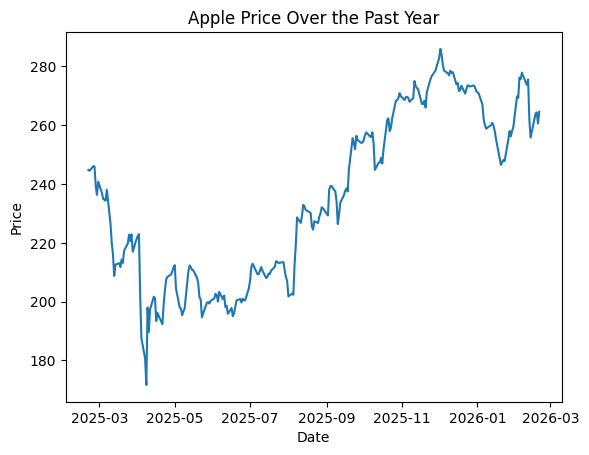

In [4]:
plt.plot(AAPL_values.index, AAPL_values["Close"], label="AAPL Close")
plt.title("Apple Price Over the Past Year")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Based on the above graph, the data seems to trend up for the most part, except for the first few months. Without having at least a few years of data, it is hard to tell whether there are seasonal trends. But based on how stocks often work, I doubt there is a seasonal trend. I think a time series approach to this problem is somewhat valid, as the stock tends to generally trend upwards independent of other factors.

## Part 1(b)

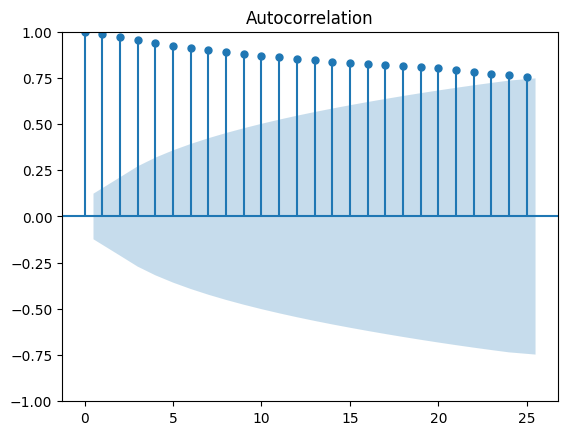

In [5]:
plot_acf(AAPL_values)
plt.show()

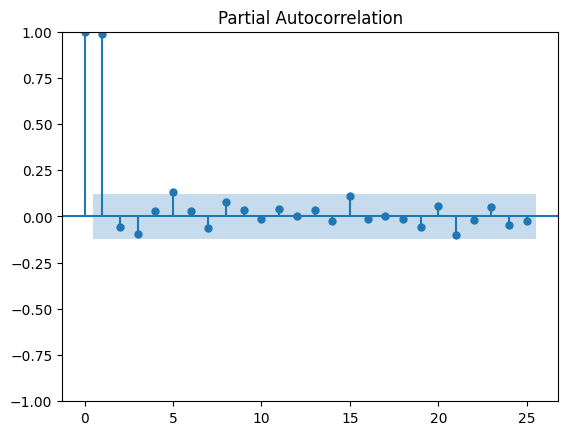

In [6]:
plot_pacf(AAPL_values)
plt.show()

From the graphs above, we can see that ACF trends down over time, and PACF has a sharp drop at around lag 2. This would suggest an AR(2) model would be best for this data.

## Part 2(a)

In [7]:
train_size = int(0.8 * len(AAPL_values))
train_data = AAPL_values[:train_size]
test_data = AAPL_values[train_size:]

y_train = np.array(train_data).reshape(-1, 1)
y_test = np.array(test_data).reshape(-1, 1)

In [8]:
p = 2

ar_model = AutoReg(y_train, lags=p, trend='n')
ar_results = ar_model.fit()

print(ar_results.summary())
print(np.abs(ar_results.roots))

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  201
Model:                     AutoReg(2)   Log Likelihood                -580.161
Method:               Conditional MLE   S.D. of innovations              4.466
Date:                Fri, 20 Feb 2026   AIC                           1166.321
Time:                        18:57:24   BIC                           1176.201
Sample:                             2   HQIC                          1170.320
                                  201                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
y.L1           1.0909      0.071     15.444      0.000       0.952       1.229
y.L2          -0.0903      0.071     -1.278      0.201      -0.229       0.048
                                    Roots           

The stationary assumption is barely violated. a root of 0.99938 is barely less than 1.

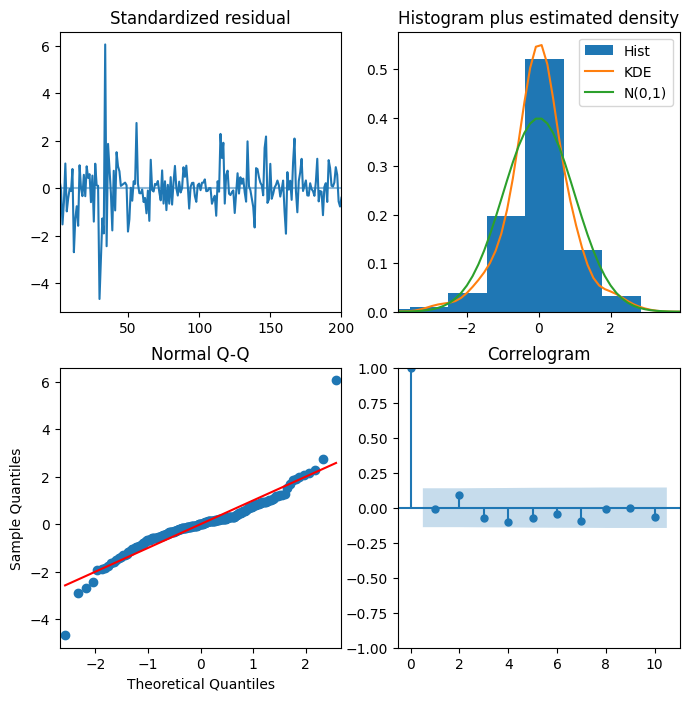

In [32]:
ar_results.plot_diagnostics(figsize=(8,8))
plt.show()

Standardized residuals: Looks good, residuals fluctuate around 0

Histogram plus estimated density: Looks good, bell shaped curve around 0, no skew

Normal Q-Q: Looks good, points mostly lie on and near the line

Correlogram: Looks good, lag 0 is 1, the rest flucuate around 0 with no patterns

Lag 1's coefficient being positive indicates a steady upward trend in the stock price. Lag 2's coefficient is negative, but the p-value being 0.2 indicates its weak.

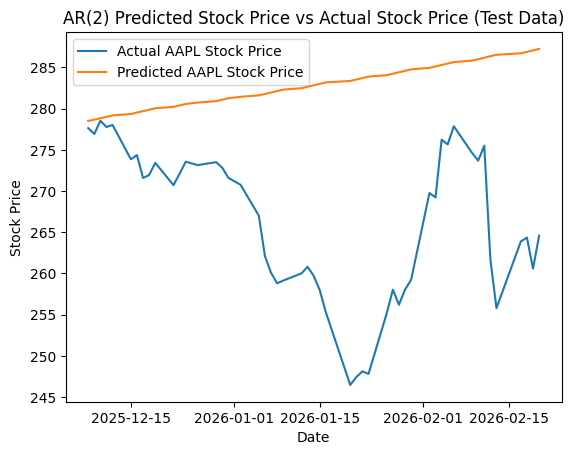

In [10]:
ar_pred = ar_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)

plt.plot(test_data.index, test_data['Close'], label='Actual AAPL Stock Price')
plt.plot(test_data.index, ar_pred, label='Predicted AAPL Stock Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('AR(2) Predicted Stock Price vs Actual Stock Price (Test Data)')
plt.legend()
plt.show()

In [23]:
ar_mae = mean_absolute_error(test_data['Close'], ar_pred)
ar_rmse = np.sqrt(mean_squared_error(test_data['Close'], ar_pred))

print("MAE:", ar_mae)
print("RMSE:", ar_rmse)

MAE: 16.703343778020862
RMSE: 19.667951779366263


## Part 2(b)

In [14]:
q = 1

ma_model = ARIMA(y_train, order=(0, 0, q))
ma_results = ma_model.fit()

print(ma_results.summary())
print(np.abs(ma_results.maroots))

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  201
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -828.922
Date:                Fri, 20 Feb 2026   AIC                           1663.844
Time:                        19:12:26   BIC                           1673.754
Sample:                             0   HQIC                          1667.854
                                - 201                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        227.7661      2.197    103.661      0.000     223.460     232.073
ma.L1          0.8829      0.039     22.808      0.000       0.807       0.959
sigma2       221.9769     28.766      7.717      0.0

/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


root is >1 so stationary assumption is met

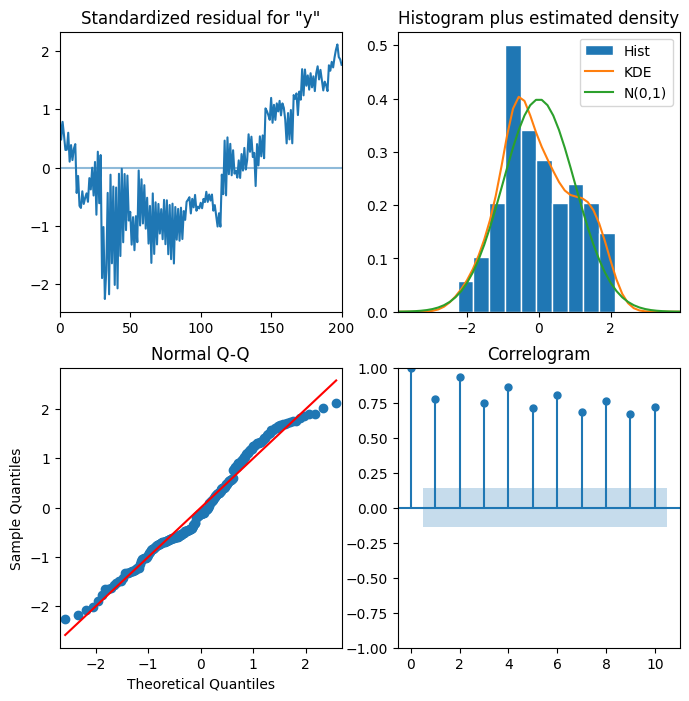

In [35]:
ma_results.plot_diagnostics(figsize=(8,8))
plt.show()

Standardized residuals: Not good, not fluctuating around 0, trends down then up

Histogram plus estimated density: Not good, left skewed

Normal Q-Q: Looks good, points mostly lie on and near the line

Correlogram: Not good, lags after 0 are not near 0

first coefficient (const) indicates the average for the stock price from the model is around 227.7661. ma.l1 of 0.8829 indicates a large positive shock from the previous term. sigma2 of 221 is the vairance of the noise.

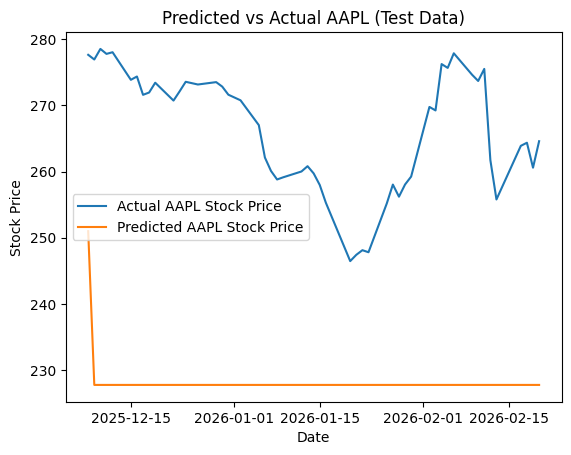

In [ ]:
ma_pred = ma_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)

plt.plot(test_data.index, test_data['Close'], label='Actual AAPL Stock Price')
plt.plot(test_data.index, ma_pred, label='Predicted AAPL Stock Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Predicted vs Actual AAPL (Test Data)')
plt.legend()
plt.show()

In [24]:
ma_mae = mean_absolute_error(test_data['Close'], ma_pred)
ma_rmse = np.sqrt(mean_squared_error(test_data['Close'], ma_pred))

print("MAE:", ma_mae)
print("RMSE:", ma_rmse)

MAE: 37.91692932048662
RMSE: 38.98997294182081


## Part 2(c)

In [29]:
p, d, q = 2, 1, 1

arima_model = ARIMA(y_train, order=(p, d, q), trend='n')
arima_results = arima_model.fit()

print(arima_results.summary())
print("abs(AR roots):", np.abs(arima_results.arroots))
print("abs(MA roots):", np.abs(arima_results.maroots))

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  201
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -581.631
Date:                Fri, 20 Feb 2026   AIC                           1171.263
Time:                        19:45:11   BIC                           1184.456
Sample:                             0   HQIC                          1176.602
                                - 201                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2277      0.535     -0.425      0.670      -1.276       0.821
ar.L2          0.1243      0.077      1.623      0.105      -0.026       0.274
ma.L1          0.3137      0.538      0.583      0.5

/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


roots are >1 so stationary assumption is met

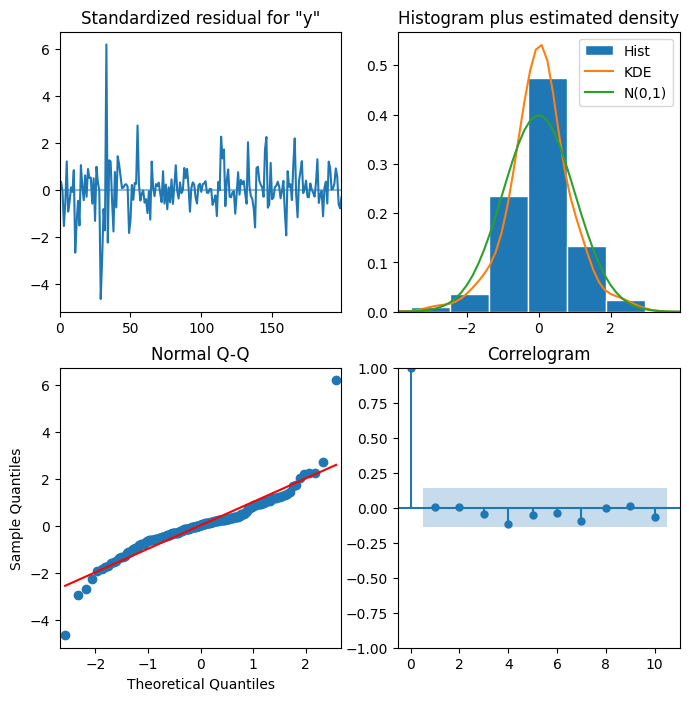

In [34]:
arima_results.plot_diagnostics(figsize=(8,8))
plt.show()

Standardized residuals: Looks good, values flucuate around 0

Histogram plus estimated density: Looks good, bell curve no large skew

Normal Q-Q: Looks good, points mostly lie on and near the line

Correlogram: Looks good, lags after 0 are around 0

Since all the p values are above 0.05, the lag coefficients may be bad predictors, claims made from the coefficients should be done cautiously.

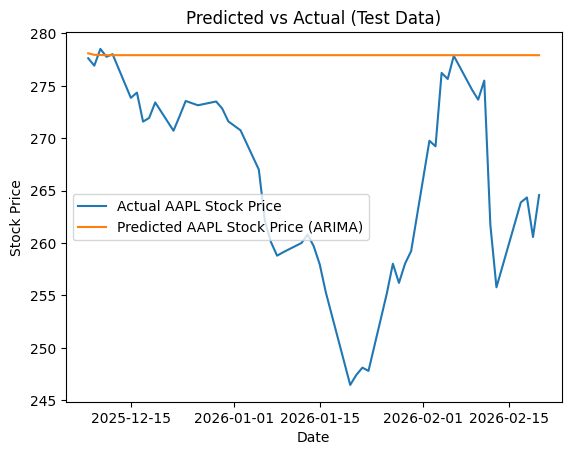

In [36]:
arima_pred = arima_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)

plt.plot(test_data.index, test_data['Close'], label='Actual AAPL Stock Price')
plt.plot(test_data.index, arima_pred, label='Predicted AAPL Stock Price (ARIMA)')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Predicted vs Actual (Test Data)')
plt.legend()
plt.show()

In [37]:
arima_mae = mean_absolute_error(test_data['Close'], arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test_data['Close'], arima_pred))

print("MAE:", arima_mae)
print("RMSE:", arima_rmse)

MAE: 11.814856613742464
RMSE: 14.882305419282531


## Part 2(d)

Out of AR and MA, it is clear that AR does a better job of prediciting Apple's stock price, but it is still not great. ARIMA out of the 3 models did the best visually, based on the graphs of the prediction vs the test data, and had the lowest MAE and RMSE. Therefore I conclude that ARIMA was the best model to predict the data. The difficulty of predicting Apple's stock price implies that the stock data is complex and hard to predict, at least just based on these simple time series. I don't think the models are worth using. The most accurate model, the ARIMA model, did not have strong lag coefficients. I believe adding more external factors such as other market data, shifts in supply and demand, and other factors would help the model.